# RAG Retrieval Improvements

Learning objective: understand why retrieval quality matters in RAG and how query rewrite, HyDE, reranking, and chunk size can change retrieval results.

## Before you start

If the required libraries are not installed yet:

1. Open a terminal
2. Run:

```bash
python -m pip install -r requirements.txt
```

3. Return to this notebook
4. Restart the kernel if needed
5. Run the cells from top to bottom

This notebook is written for careful reading.

Do not rush to the final answer.

The important part is the retrieval process.

## Local model note

Optional local generation in this notebook uses this default DataHub model path:

```text
/home/jovyan/shared/qwen2-1_5b-instruct-q4_0.gguf
```

If the file does not exist, the retrieval part of the notebook will still work.

Only the local generation step will be skipped.

In [1]:
# numpy helps us work with numbers
import numpy

# matplotlib helps us draw simple plots
import matplotlib.pyplot as plt

# sentence_transformers provides embedding models
from sentence_transformers import SentenceTransformer

# cosine_similarity compares vectors
from sklearn.metrics.pairwise import cosine_similarity

# os checks whether files exist
import os

# llama_cpp loads a local GGUF model when available
try:
    from llama_cpp import Llama
    local_llm_support = True
except Exception:
    print("llama-cpp-python is not installed. The optional local generation step will be skipped.")
    local_llm_support = False

## What this notebook does

This notebook is about retrieval.

We will start with a simple retrieval baseline.

Then we will improve it step by step.

We will compare:

- a clear question
- a vague question
- a rewritten question
- a HyDE query
- a reranked result
- two chunk sizes

We will also build a context and inspect an evidence-based answer.

At the end, there are optional local, OpenAI, and Claude comparison steps.

## Step 1: Prepare a small document collection

A document collection is the set of texts we want to search.

For teaching, we will use short university-style documents.

This makes the retrieval results easy to inspect by eye.

In [2]:
documents = []

documents.append("The university library is open from 8 AM to 10 PM on weekdays. On weekends, the library is open from 10 AM to 6 PM.")
documents.append("Students can apply for financial aid between March 1 and April 15. The application requires academic records and financial documents.")
documents.append("Graduate students may apply for teaching assistant positions. Applications are reviewed by the department each semester.")
documents.append("The campus gym is open to students with a valid student ID. Guests need a temporary pass.")
documents.append("Parking permits for students must be renewed every semester. Permits can be purchased through the campus transportation office.")
documents.append("Scholarships are available for students with strong academic performance. Some scholarships require separate applications.")

## Inspect the raw documents

Before building retrieval, we should inspect the documents.

A retrieval system can only retrieve what is stored.

If the documents are unclear, retrieval can also become unclear.

In [3]:
document_index = 0

for document_text in documents:
    print("Document number:", document_index)
    print(document_text)
    print()

    document_index = document_index + 1

Document number: 0
The university library is open from 8 AM to 10 PM on weekdays. On weekends, the library is open from 10 AM to 6 PM.

Document number: 1
Students can apply for financial aid between March 1 and April 15. The application requires academic records and financial documents.

Document number: 2
Graduate students may apply for teaching assistant positions. Applications are reviewed by the department each semester.

Document number: 3
The campus gym is open to students with a valid student ID. Guests need a temporary pass.

Document number: 4
Parking permits for students must be renewed every semester. Permits can be purchased through the campus transportation office.

Document number: 5
Scholarships are available for students with strong academic performance. Some scholarships require separate applications.



## Step 2: Split the documents into chunks

A chunk is a smaller piece of text.

Why do we use chunks?

A long document may contain several ideas.
A smaller chunk often helps retrieval focus on a narrower region.

We will start with one chunk size.
Later, we will compare it with a smaller chunk size.

In [4]:
chunk_size = 120
chunk_overlap = 20

chunk_records = []

document_index = 0

for document_text in documents:
    start_position = 0
    chunk_number = 0
    text_length = len(document_text)

    while start_position < text_length:
        end_position = start_position + chunk_size
        chunk_text = document_text[start_position:end_position]

        if chunk_text.strip() != "":
            chunk_record = {
                "source_name": "document_" + str(document_index),
                "chunk_number": chunk_number,
                "text": chunk_text.strip()
            }

            chunk_records.append(chunk_record)
            chunk_number = chunk_number + 1

        step_size = chunk_size - chunk_overlap

        if step_size <= 0:
            step_size = chunk_size

        start_position = start_position + step_size

    document_index = document_index + 1

## Inspect the chunks

This is one of the most important views in RAG.

If chunking is poor, retrieval is often poor.

Questions to think about:

- Are the chunks too short?
- Are the chunks too long?
- Does each chunk focus on one main idea, or several ideas at once?

In [5]:
chunk_index = 0

for chunk_record in chunk_records:
    print("Chunk index:", chunk_index)
    print("Source:", chunk_record["source_name"])
    print("Chunk number:", chunk_record["chunk_number"])
    print(chunk_record["text"])
    print()

    chunk_index = chunk_index + 1

Chunk index: 0
Source: document_0
Chunk number: 0
The university library is open from 8 AM to 10 PM on weekdays. On weekends, the library is open from 10 AM to 6 PM.

Chunk index: 1
Source: document_0
Chunk number: 1
10 AM to 6 PM.

Chunk index: 2
Source: document_1
Chunk number: 0
Students can apply for financial aid between March 1 and April 15. The application requires academic records and financi

Chunk index: 3
Source: document_1
Chunk number: 1
records and financial documents.

Chunk index: 4
Source: document_2
Chunk number: 0
Graduate students may apply for teaching assistant positions. Applications are reviewed by the department each semester.

Chunk index: 5
Source: document_2
Chunk number: 1
tment each semester.

Chunk index: 6
Source: document_3
Chunk number: 0
The campus gym is open to students with a valid student ID. Guests need a temporary pass.

Chunk index: 7
Source: document_4
Chunk number: 0
Parking permits for students must be renewed every semester. Permits can be 

## Step 3: Load an embedding model

An embedding is a vector of numbers that represents meaning.

The numbers themselves are not important to humans.

What matters is this:

texts with similar meanings often have similar vectors.

In [6]:
embedding_model_name = "all-MiniLM-L6-v2"

embedding_model = SentenceTransformer(embedding_model_name)

print("Loaded embedding model:")
print(embedding_model_name)

Loaded embedding model:
all-MiniLM-L6-v2


## Step 4: Create embeddings for all chunks

Now we convert each chunk into an embedding vector.

This will let us compare the question with every chunk.

In [7]:
chunk_embeddings = []

for chunk_record in chunk_records:
    chunk_embedding = embedding_model.encode(chunk_record["text"])
    chunk_embeddings.append(chunk_embedding)

print("Number of chunk embeddings:")
print(len(chunk_embeddings))

Number of chunk embeddings:
11


## Step 5: Ask a clear question

We will start with a clear question.

Before retrieval, try to predict which chunk should rank near the top.

In [8]:
clear_question = "When can students apply for financial aid?"

print("Clear question:")
print(clear_question)

clear_question_embedding = embedding_model.encode(clear_question)

Clear question:
When can students apply for financial aid?


## Step 6: Compute similarity scores for the clear question

We use cosine similarity to compare the question embedding with each chunk embedding.

A higher score usually means a stronger semantic match.

In [9]:
clear_similarity_scores = []

for chunk_embedding in chunk_embeddings:
    similarity_value = cosine_similarity([clear_question_embedding], [chunk_embedding])[0][0]
    clear_similarity_scores.append(similarity_value)

## Inspect all similarity scores

Do not jump directly to the final answer.

A good retrieval workflow includes inspecting the chunks and their scores.

This makes retrieval visible.

In [10]:
chunk_index = 0

for similarity_value in clear_similarity_scores:
    print("Chunk index:", chunk_index)
    print("Similarity score:", similarity_value)
    print(chunk_records[chunk_index]["text"])
    print()

    chunk_index = chunk_index + 1

Chunk index: 0
Similarity score: 0.29048663
The university library is open from 8 AM to 10 PM on weekdays. On weekends, the library is open from 10 AM to 6 PM.

Chunk index: 1
Similarity score: 0.09584958
10 AM to 6 PM.

Chunk index: 2
Similarity score: 0.8671998
Students can apply for financial aid between March 1 and April 15. The application requires academic records and financi

Chunk index: 3
Similarity score: 0.2133488
records and financial documents.

Chunk index: 4
Similarity score: 0.3622629
Graduate students may apply for teaching assistant positions. Applications are reviewed by the department each semester.

Chunk index: 5
Similarity score: 0.47618896
tment each semester.

Chunk index: 6
Similarity score: 0.23642339
The campus gym is open to students with a valid student ID. Guests need a temporary pass.

Chunk index: 7
Similarity score: 0.39541543
Parking permits for students must be renewed every semester. Permits can be purchased through the campus transportation

Chunk 

## Visualize the similarity scores

This plot shows the similarity score for each chunk.

A higher bar means a stronger match.

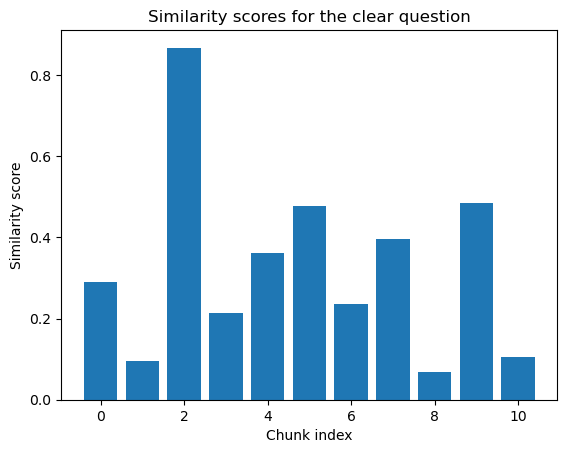

In [11]:
figure = plt.figure()
plt.bar(range(len(clear_similarity_scores)), clear_similarity_scores)
plt.title("Similarity scores for the clear question")
plt.xlabel("Chunk index")
plt.ylabel("Similarity score")
plt.show()

## Rank the chunks

Now we sort the chunks from the strongest match to the weakest match.

This makes the top results easier to inspect.

In [12]:
clear_ranked_results = []

chunk_index = 0

for similarity_value in clear_similarity_scores:
    ranked_result = (
        similarity_value,
        chunk_records[chunk_index]["source_name"],
        chunk_records[chunk_index]["chunk_number"],
        chunk_records[chunk_index]["text"]
    )

    clear_ranked_results.append(ranked_result)
    chunk_index = chunk_index + 1

clear_ranked_results = sorted(clear_ranked_results, reverse=True)

## Inspect the top 3 retrieved chunks

A top-k result means the top few retrieved results.

Here, k = 3.

In [13]:
top_count = 0

for ranked_result in clear_ranked_results:
    if top_count < 3:
        print("Rank:", top_count + 1)
        print("Score:", ranked_result[0])
        print("Source:", ranked_result[1])
        print("Chunk number:", ranked_result[2])
        print("Chunk text:", ranked_result[3])
        print()

    top_count = top_count + 1

Rank: 1
Score: 0.8671998
Source: document_1
Chunk number: 0
Chunk text: Students can apply for financial aid between March 1 and April 15. The application requires academic records and financi

Rank: 2
Score: 0.48404604
Source: document_5
Chunk number: 0
Chunk text: Scholarships are available for students with strong academic performance. Some scholarships require separate application

Rank: 3
Score: 0.47618896
Source: document_2
Chunk number: 1
Chunk text: tment each semester.



## Step 7: A failure case with a vague question

Retrieval does not always work well.

A vague question often gives weaker retrieval results because it contains less useful meaning.

In [14]:
vague_question = "When is aid?"

print("Vague question:")
print(vague_question)

vague_question_embedding = embedding_model.encode(vague_question)

Vague question:
When is aid?


## Compute similarity scores for the vague question

This repeats the same pattern on purpose.

That repetition makes comparison easier.

In [15]:
vague_similarity_scores = []

for chunk_embedding in chunk_embeddings:
    similarity_value = cosine_similarity([vague_question_embedding], [chunk_embedding])[0][0]
    vague_similarity_scores.append(similarity_value)

## Inspect the vague-question results

Questions to think about:

- Are the scores lower?
- Did the correct chunk move down?
- Why might the word `aid` be too vague?

In [16]:
chunk_index = 0

for similarity_value in vague_similarity_scores:
    print("Chunk index:", chunk_index)
    print("Similarity score:", similarity_value)
    print(chunk_records[chunk_index]["text"])
    print()

    chunk_index = chunk_index + 1

Chunk index: 0
Similarity score: 0.21163917
The university library is open from 8 AM to 10 PM on weekdays. On weekends, the library is open from 10 AM to 6 PM.

Chunk index: 1
Similarity score: 0.3044427
10 AM to 6 PM.

Chunk index: 2
Similarity score: 0.41447127
Students can apply for financial aid between March 1 and April 15. The application requires academic records and financi

Chunk index: 3
Similarity score: 0.001846686
records and financial documents.

Chunk index: 4
Similarity score: 0.10250947
Graduate students may apply for teaching assistant positions. Applications are reviewed by the department each semester.

Chunk index: 5
Similarity score: 0.20686653
tment each semester.

Chunk index: 6
Similarity score: 0.08435041
The campus gym is open to students with a valid student ID. Guests need a temporary pass.

Chunk index: 7
Similarity score: 0.06515923
Parking permits for students must be renewed every semester. Permits can be purchased through the campus transportation

Chu

## Step 8: Improve retrieval with query rewrite

A query rewrite changes the user question into a clearer retrieval query.

This can improve retrieval because the rewritten question contains more detail.

In [17]:
rewritten_question = ""
rewritten_question = rewritten_question + "Provide detailed information about: "
rewritten_question = rewritten_question + vague_question
rewritten_question = rewritten_question + ". Include important dates, rules, and requirements if available."

print("Original question:")
print(vague_question)

print()
print("Rewritten question:")
print(rewritten_question)

rewritten_question_embedding = embedding_model.encode(rewritten_question)

Original question:
When is aid?

Rewritten question:
Provide detailed information about: When is aid?. Include important dates, rules, and requirements if available.


## Retrieve again with the rewritten question

In [18]:
rewritten_similarity_scores = []

for chunk_embedding in chunk_embeddings:
    similarity_value = cosine_similarity([rewritten_question_embedding], [chunk_embedding])[0][0]
    rewritten_similarity_scores.append(similarity_value)

## Inspect the rewritten-question results

Now compare these results with the vague-question results.

Questions:

- Did the financial aid chunk move upward?
- Did the score improve?
- Why might more detail help?

In [19]:
chunk_index = 0

for similarity_value in rewritten_similarity_scores:
    print("Chunk index:", chunk_index)
    print("Similarity score:", similarity_value)
    print(chunk_records[chunk_index]["text"])
    print()

    chunk_index = chunk_index + 1

Chunk index: 0
Similarity score: 0.19699685
The university library is open from 8 AM to 10 PM on weekdays. On weekends, the library is open from 10 AM to 6 PM.

Chunk index: 1
Similarity score: 0.11128275
10 AM to 6 PM.

Chunk index: 2
Similarity score: 0.48461452
Students can apply for financial aid between March 1 and April 15. The application requires academic records and financi

Chunk index: 3
Similarity score: 0.19859573
records and financial documents.

Chunk index: 4
Similarity score: 0.20898409
Graduate students may apply for teaching assistant positions. Applications are reviewed by the department each semester.

Chunk index: 5
Similarity score: 0.3347066
tment each semester.

Chunk index: 6
Similarity score: 0.19126421
The campus gym is open to students with a valid student ID. Guests need a temporary pass.

Chunk index: 7
Similarity score: 0.21608676
Parking permits for students must be renewed every semester. Permits can be purchased through the campus transportation

Chun

## Step 9: Improve retrieval with HyDE

HyDE stands for Hypothetical Document Embedding.

Instead of embedding the short question directly, we first create a hypothetical document.
Then we embed that richer text and use it for retrieval.

In [20]:
hypothetical_document = ""
hypothetical_document = hypothetical_document + "This document explains the topic: "
hypothetical_document = hypothetical_document + clear_question
hypothetical_document = hypothetical_document + ". It contains important facts, dates, requirements, and explanations."

print("Hypothetical document:")
print(hypothetical_document)

hypothetical_document_embedding = embedding_model.encode(hypothetical_document)

Hypothetical document:
This document explains the topic: When can students apply for financial aid?. It contains important facts, dates, requirements, and explanations.


## Retrieve with HyDE

In [21]:
hyde_similarity_scores = []

for chunk_embedding in chunk_embeddings:
    similarity_value = cosine_similarity([hypothetical_document_embedding], [chunk_embedding])[0][0]
    hyde_similarity_scores.append(similarity_value)

## Inspect the HyDE results

Now compare HyDE with:
- the clear question
- the vague question
- the rewritten question

In [22]:
chunk_index = 0

for similarity_value in hyde_similarity_scores:
    print("Chunk index:", chunk_index)
    print("Similarity score:", similarity_value)
    print(chunk_records[chunk_index]["text"])
    print()

    chunk_index = chunk_index + 1

Chunk index: 0
Similarity score: 0.2866723
The university library is open from 8 AM to 10 PM on weekdays. On weekends, the library is open from 10 AM to 6 PM.

Chunk index: 1
Similarity score: 0.013880029
10 AM to 6 PM.

Chunk index: 2
Similarity score: 0.7476392
Students can apply for financial aid between March 1 and April 15. The application requires academic records and financi

Chunk index: 3
Similarity score: 0.3187928
records and financial documents.

Chunk index: 4
Similarity score: 0.28972238
Graduate students may apply for teaching assistant positions. Applications are reviewed by the department each semester.

Chunk index: 5
Similarity score: 0.4376029
tment each semester.

Chunk index: 6
Similarity score: 0.19835797
The campus gym is open to students with a valid student ID. Guests need a temporary pass.

Chunk index: 7
Similarity score: 0.3461371
Parking permits for students must be renewed every semester. Permits can be purchased through the campus transportation

Chunk i

## Compare the top score across methods

This plot compares the best score from:

- clear question
- vague question
- rewritten question
- HyDE

This is not the whole story, but it gives a useful summary.

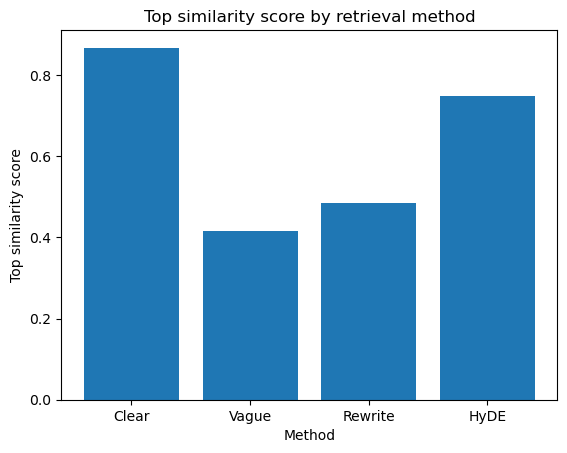

In [23]:
clear_top_score = max(clear_similarity_scores)
vague_top_score = max(vague_similarity_scores)
rewrite_top_score = max(rewritten_similarity_scores)
hyde_top_score = max(hyde_similarity_scores)

method_names = []
method_names.append("Clear")
method_names.append("Vague")
method_names.append("Rewrite")
method_names.append("HyDE")

top_scores = []
top_scores.append(clear_top_score)
top_scores.append(vague_top_score)
top_scores.append(rewrite_top_score)
top_scores.append(hyde_top_score)

figure = plt.figure()
plt.bar(method_names, top_scores)
plt.title("Top similarity score by retrieval method")
plt.xlabel("Method")
plt.ylabel("Top similarity score")
plt.show()

## Step 10: Improve retrieval with reranking

Initial retrieval is not always perfect.

A reranker tries to reorder the retrieved chunks more carefully.

Here we will use a simple embedding-based reranking step.

In [24]:
initial_top_results = []

top_count = 0

for ranked_result in clear_ranked_results:
    if top_count < 5:
        initial_top_results.append(ranked_result)

    top_count = top_count + 1

## Compute rerank scores for the top results

We will compare the question with the top retrieved chunks again.
Then we will reorder those candidates.

In [25]:
reranked_results = []

for ranked_result in initial_top_results:
    result_embedding = embedding_model.encode(ranked_result[3])
    rerank_score = cosine_similarity([clear_question_embedding], [result_embedding])[0][0]

    reranked_result = (
        ranked_result[0],
        rerank_score,
        ranked_result[1],
        ranked_result[2],
        ranked_result[3]
    )

    reranked_results.append(reranked_result)

reranked_results = sorted(reranked_results, reverse=True)

## Compare before and after reranking

Questions:

- Did the top result change?
- Did a more relevant chunk move upward?
- Why might reranking help when several chunks look similar?

In [26]:
print("Before reranking:")
print()

rank_number = 1

for ranked_result in initial_top_results:
    print("Rank:", rank_number)
    print("Score:", ranked_result[0])
    print(ranked_result[3])
    print()
    rank_number = rank_number + 1

print("After reranking:")
print()

rank_number = 1

for reranked_result in reranked_results:
    print("Rank:", rank_number)
    print("Original score:", reranked_result[0])
    print("Rerank score:", reranked_result[1])
    print(reranked_result[4])
    print()
    rank_number = rank_number + 1

Before reranking:

Rank: 1
Score: 0.8671998
Students can apply for financial aid between March 1 and April 15. The application requires academic records and financi

Rank: 2
Score: 0.48404604
Scholarships are available for students with strong academic performance. Some scholarships require separate application

Rank: 3
Score: 0.47618896
tment each semester.

Rank: 4
Score: 0.39541543
Parking permits for students must be renewed every semester. Permits can be purchased through the campus transportation

Rank: 5
Score: 0.3622629
Graduate students may apply for teaching assistant positions. Applications are reviewed by the department each semester.

After reranking:

Rank: 1
Original score: 0.8671998
Rerank score: 0.8671998
Students can apply for financial aid between March 1 and April 15. The application requires academic records and financi

Rank: 2
Original score: 0.48404604
Rerank score: 0.48404604
Scholarships are available for students with strong academic performance. Some scholar

## Visualize reranking before and after

This plot compares:

- original retrieval score
- rerank score

for the same retrieved candidates.

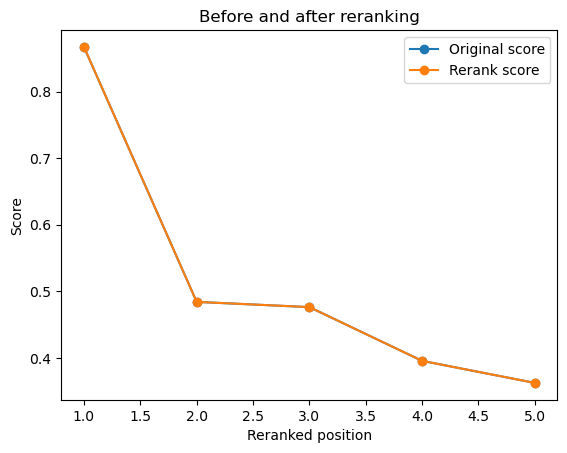

In [27]:
rerank_positions = []
original_scores = []
new_rerank_scores = []

rank_number = 1

for reranked_result in reranked_results:
    rerank_positions.append(rank_number)
    original_scores.append(reranked_result[0])
    new_rerank_scores.append(reranked_result[1])
    rank_number = rank_number + 1

figure = plt.figure()
plt.plot(rerank_positions, original_scores, marker="o", label="Original score")
plt.plot(rerank_positions, new_rerank_scores, marker="o", label="Rerank score")
plt.title("Before and after reranking")
plt.xlabel("Reranked position")
plt.ylabel("Score")
plt.legend()
plt.show()

## Step 11: Compare chunk sizes

Chunk size can change retrieval quality.

Now we will run a small chunking experiment with a smaller chunk size.

In [28]:
small_chunk_size = 80
small_chunk_overlap = 10

small_chunk_records = []

document_index = 0

for document_text in documents:
    start_position = 0
    chunk_number = 0
    text_length = len(document_text)

    while start_position < text_length:
        end_position = start_position + small_chunk_size
        chunk_text = document_text[start_position:end_position]

        if chunk_text.strip() != "":
            chunk_record = {
                "source_name": "document_" + str(document_index),
                "chunk_number": chunk_number,
                "text": chunk_text.strip()
            }

            small_chunk_records.append(chunk_record)
            chunk_number = chunk_number + 1

        step_size = small_chunk_size - small_chunk_overlap

        if step_size <= 0:
            step_size = small_chunk_size

        start_position = start_position + step_size

    document_index = document_index + 1

## Create embeddings for the smaller chunks

In [29]:
small_chunk_embeddings = []

for chunk_record in small_chunk_records:
    chunk_embedding = embedding_model.encode(chunk_record["text"])
    small_chunk_embeddings.append(chunk_embedding)

## Retrieve with the smaller chunks

In [30]:
small_chunk_similarity_scores = []

for chunk_embedding in small_chunk_embeddings:
    similarity_value = cosine_similarity([clear_question_embedding], [chunk_embedding])[0][0]
    small_chunk_similarity_scores.append(similarity_value)

## Inspect the top results with smaller chunks

Questions:

- Did the top chunk change?
- Did the smaller chunk isolate the answer more clearly?
- Is the smaller chunk too short?

In [31]:
small_chunk_ranked_results = []

chunk_index = 0

for similarity_value in small_chunk_similarity_scores:
    ranked_result = (
        similarity_value,
        small_chunk_records[chunk_index]["source_name"],
        small_chunk_records[chunk_index]["chunk_number"],
        small_chunk_records[chunk_index]["text"]
    )

    small_chunk_ranked_results.append(ranked_result)
    chunk_index = chunk_index + 1

small_chunk_ranked_results = sorted(small_chunk_ranked_results, reverse=True)

top_count = 0

for ranked_result in small_chunk_ranked_results:
    if top_count < 3:
        print("Rank:", top_count + 1)
        print("Score:", ranked_result[0])
        print("Source:", ranked_result[1])
        print("Chunk number:", ranked_result[2])
        print("Chunk text:", ranked_result[3])
        print()

    top_count = top_count + 1

Rank: 1
Score: 0.8577203
Source: document_1
Chunk number: 0
Chunk text: Students can apply for financial aid between March 1 and April 15. The applicati

Rank: 2
Score: 0.5183866
Source: document_5
Chunk number: 1
Chunk text: ce. Some scholarships require separate applications.

Rank: 3
Score: 0.46917275
Source: document_5
Chunk number: 0
Chunk text: Scholarships are available for students with strong academic performance. Some s



## Compare the top score for two chunk sizes

This plot compares:

- the original chunk size
- the smaller chunk size

The top score is not the only thing that matters, but it is a useful summary.

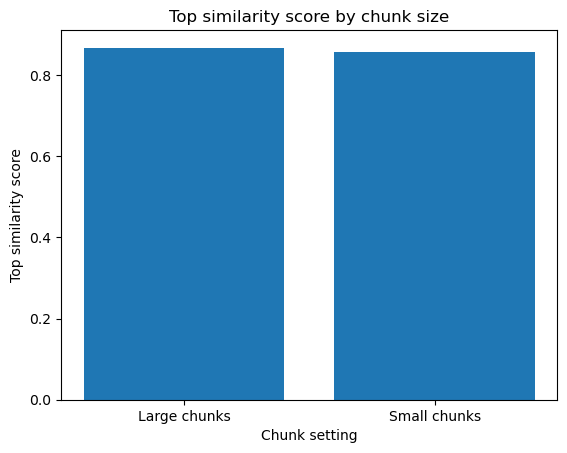

In [32]:
large_chunk_top_score = clear_ranked_results[0][0]
small_chunk_top_score = small_chunk_ranked_results[0][0]

chunk_size_names = []
chunk_size_names.append("Large chunks")
chunk_size_names.append("Small chunks")

chunk_size_scores = []
chunk_size_scores.append(large_chunk_top_score)
chunk_size_scores.append(small_chunk_top_score)

figure = plt.figure()
plt.bar(chunk_size_names, chunk_size_scores)
plt.title("Top similarity score by chunk size")
plt.xlabel("Chunk setting")
plt.ylabel("Top similarity score")
plt.show()

## Step 12: Build a context from top results

A context is the text we pass to the language model.

In RAG, context usually comes from the top retrieved chunks.

In [33]:
context_text = ""

top_count = 0

for ranked_result in clear_ranked_results:
    if top_count < 3:
        context_text = context_text + ranked_result[3]
        context_text = context_text + "

"

    top_count = top_count + 1

print("Context:")
print(context_text)

SyntaxError: unterminated string literal (detected at line 8) (3802627066.py, line 8)

## Step 13: Build an evidence-based answer

Before calling a language model, we should inspect the evidence directly.

This helps us ask:
- Is the retrieval result good enough?
- Would a generated answer be trustworthy?

In [ ]:
evidence_based_answer = ""
evidence_based_answer = evidence_based_answer + "Question: "
evidence_based_answer = evidence_based_answer + clear_question
evidence_based_answer = evidence_based_answer + "

"
evidence_based_answer = evidence_based_answer + "Most relevant evidence:
"
evidence_based_answer = evidence_based_answer + clear_ranked_results[0][3]

print(evidence_based_answer)

## Optional step: local generation with a GGUF model

This step is optional.

It needs:
- `llama-cpp-python`
- a GGUF model file

The default path below is the DataHub path.

In [ ]:
model_file_path = "/home/jovyan/shared/qwen2-1_5b-instruct-q4_0.gguf"

generated_answer = ""

if local_llm_support is True and os.path.exists(model_file_path) is True:
    local_model = Llama(
        model_path=model_file_path,
        n_ctx=2048,
        n_threads=4,
        verbose=False
    )

    generation_prompt = ""
    generation_prompt = generation_prompt + "Use the context to answer the question.

"
    generation_prompt = generation_prompt + "Context:
"
    generation_prompt = generation_prompt + context_text
    generation_prompt = generation_prompt + "
Question:
"
    generation_prompt = generation_prompt + clear_question
    generation_prompt = generation_prompt + "

Answer:
"

    generated_output = local_model(
        generation_prompt,
        max_tokens=200,
        temperature=0.2
    )

    generated_answer = generated_output["choices"][0]["text"]

    print("Generated answer:")
    print(generated_answer)
else:
    print("Local generation was skipped.")
    print("Either llama-cpp-python is missing or the GGUF model file was not found.")

## Optional step: API answer comparison

If API packages and keys are available, we can compare local and API answers.

This section is optional.
The notebook still works without it.

In [ ]:
openai_generated_answer = ""
claude_generated_answer = ""

try:
    from dotenv import load_dotenv
    dotenv_support = True
except Exception:
    dotenv_support = False

try:
    from openai import OpenAI
    openai_api_support = True
except Exception:
    openai_api_support = False

try:
    from anthropic import Anthropic
    anthropic_api_support = True
except Exception:
    anthropic_api_support = False

if dotenv_support is True:
    load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
anthropic_api_key = os.getenv("ANTHROPIC_API_KEY")

api_prompt = ""
api_prompt = api_prompt + "Use the context to answer the question.

"
api_prompt = api_prompt + "Context:
"
api_prompt = api_prompt + context_text
api_prompt = api_prompt + "
Question:
"
api_prompt = api_prompt + clear_question
api_prompt = api_prompt + "

Answer:
"

if openai_api_support is True and openai_api_key is not None and openai_api_key.strip() != "":
    openai_client = OpenAI(api_key=openai_api_key)

    openai_response = openai_client.responses.create(
        model="gpt-5-mini",
        instructions="You are a helpful assistant. Answer using only the retrieved context.",
        input="Context:
" + context_text + "
Question:
" + clear_question,
        max_output_tokens=200,
        temperature=0.2
    )

    openai_generated_answer = openai_response.output_text
    print("OpenAI answer:")
    print(openai_generated_answer)
else:
    print("OpenAI answer was skipped.")

print()

if anthropic_api_support is True and anthropic_api_key is not None and anthropic_api_key.strip() != "":
    claude_client = Anthropic(api_key=anthropic_api_key)

    claude_response = claude_client.messages.create(
        model="claude-haiku-4-5",
        max_tokens=200,
        temperature=0.2,
        messages=[{"role": "user", "content": api_prompt}]
    )

    for content_block in claude_response.content:
        if hasattr(content_block, "text"):
            claude_generated_answer = claude_generated_answer + content_block.text

    print("Claude answer:")
    print(claude_generated_answer)
else:
    print("Claude answer was skipped.")

## Answer comparison panel

This is a useful final comparison.

We now compare:

- evidence-based answer
- local generated answer, if available
- OpenAI answer, if available
- Claude answer, if available

Questions:

- Which answer is most grounded in the retrieved chunks?
- Which answer sounds more natural?
- Did any answer add unsupported information?

In [ ]:
print("Evidence-based answer:")
print()
print(evidence_based_answer)

print()
print("Local generated answer:")
if generated_answer != "":
    print(generated_answer)
else:
    print("Local generated answer is not available.")

print()
print("OpenAI answer:")
if openai_generated_answer != "":
    print(openai_generated_answer)
else:
    print("OpenAI answer is not available.")

print()
print("Claude answer:")
if claude_generated_answer != "":
    print(claude_generated_answer)
else:
    print("Claude answer is not available.")

## Reflection questions

1. Which retrieval setting worked best?
2. Why did the vague question perform worse?
3. Did query rewrite improve the match?
4. Did HyDE change the top result?
5. Did reranking change the order in a useful way?
6. How did chunk size affect retrieval?
7. Which answer was most grounded in the evidence?

## Optional advanced section

The main lesson ends here.

The next cells give a more observability-style view of retrieval.
They are optional.

## Retrieved chunk table

This is a more inspection-oriented view.

It looks more like the kind of table you might inspect in a practical RAG debugging workflow.

In [ ]:
print("Retrieved chunk table:")
print()

rank_number = 1

for ranked_result in clear_ranked_results:
    if rank_number <= 5:
        print("Rank:", rank_number)
        print("Score:", ranked_result[0])
        print("Source:", ranked_result[1])
        print("Chunk number:", ranked_result[2])
        print("Chunk text:", ranked_result[3])
        print()

    rank_number = rank_number + 1

## Retrieval flow summary

This is a simplified, observability-style summary of the pipeline.

It helps show the relationship between:

- question
- retrieval query
- retrieved chunks
- final context
- final answer

In [ ]:
print("Original question:")
print(clear_question)

print()
print("Example rewritten query:")
print(rewritten_question)

print()
print("Example HyDE query:")
print(hypothetical_document)

print()
print("Final context:")
print(context_text)

print()
print("Evidence-based answer:")
print(evidence_based_answer)

## Challenge tasks

1. Change the question and test retrieval again.
2. Write your own vague question and then rewrite it.
3. Compare two chunk sizes of your choice.
4. Decide whether query rewrite or HyDE helped more.
5. Try a different small corpus and inspect the top chunks.
6. If a local model or API is available, compare the evidence-based answer with generated answers.

## Summary

In this notebook, you practiced:

- document preparation
- chunking
- embeddings
- retrieval
- failure analysis
- query rewrite
- HyDE
- reranking
- chunk-size comparison
- context building
- evidence-based inspection
- optional local generation
- optional API comparison
- optional observability-style inspection

Most important idea:

Better retrieval usually leads to better answers.